In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from scipy.stats import chi2_contingency
from sklearn.feature_selection import RFE,SequentialFeatureSelector as SFS
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

In [2]:
data = pd.read_csv("dataset_churn.csv")
data.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,One year,Mailed check,71.88,931.49,No,No,Yes,No,No
1,1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,Two year,Mailed check,110.99,1448.46,Yes,Yes,No,No,No
2,2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,Month-to-month,Mailed check,116.74,6997.73,Yes,Yes,No,No,No
3,3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.16,4452.13,No,Yes,No,Yes,No
4,4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,Two year,Electronic check,30.33,1569.73,Yes,No,Yes,Yes,No


##  Data exploration

In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3749 non-null   int64  
 1   CustomerID        3749 non-null   object 
 2   Age               3562 non-null   float64
 3   Gender            3749 non-null   object 
 4   Tenure            3749 non-null   int64  
 5   Service_Internet  3028 non-null   object 
 6   Service_Phone     3749 non-null   object 
 7   Service_TV        3749 non-null   object 
 8   Contract          3749 non-null   object 
 9   PaymentMethod     3562 non-null   object 
 10  MonthlyCharges    3749 non-null   float64
 11  TotalCharges      3749 non-null   float64
 12  StreamingMovies   3749 non-null   object 
 13  StreamingMusic    3749 non-null   object 
 14  OnlineSecurity    3749 non-null   object 
 15  TechSupport       3749 non-null   object 
 16  Churn             3749 non-null   object 


,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges
count,3749.000000,3562.000000,3749.000000,3749.000000,3749.000000
mean,1874.000000,43.655531,36.264070,75.844318,2718.968266
std,1082.387408,14.914474,20.505528,73.062971,3211.879149
min,0.000000,18.000000,1.000000,20.000000,13.190000
25%,937.000000,31.000000,19.000000,44.570000,1076.240000
50%,1874.000000,44.000000,36.000000,69.590000,2132.260000
75%,2811.000000,56.000000,54.000000,95.540000,3619.710000
max,3748.000000,69.000000,71.000000,1179.300000,79951.800000


### Visualisation

In [4]:
numerical_features = ['Age','Tenure','MonthlyCharges','TotalCharges']

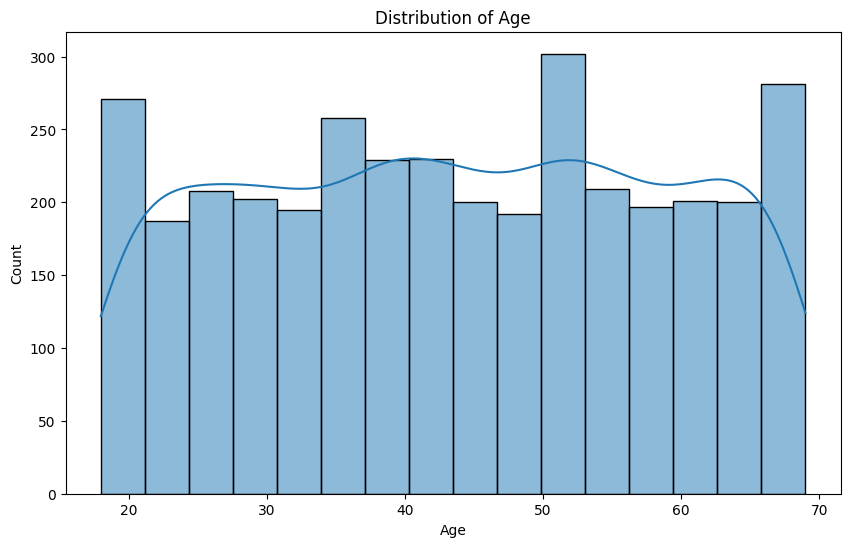

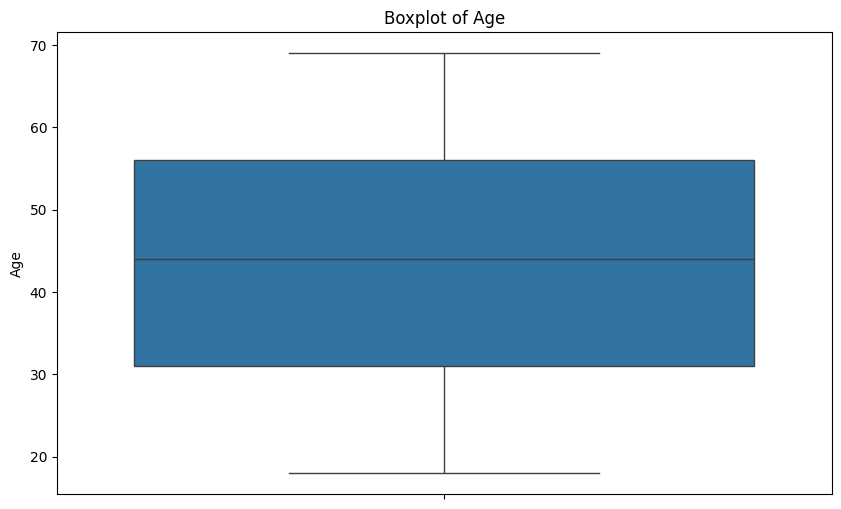

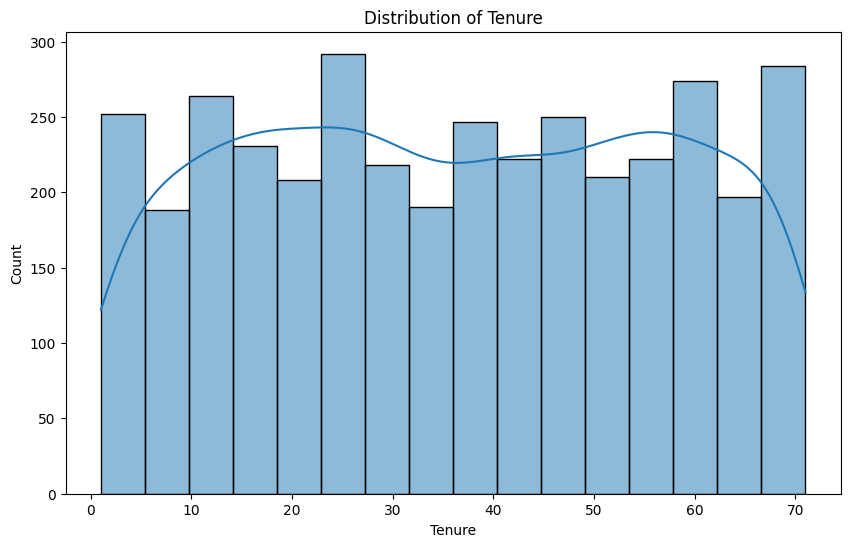

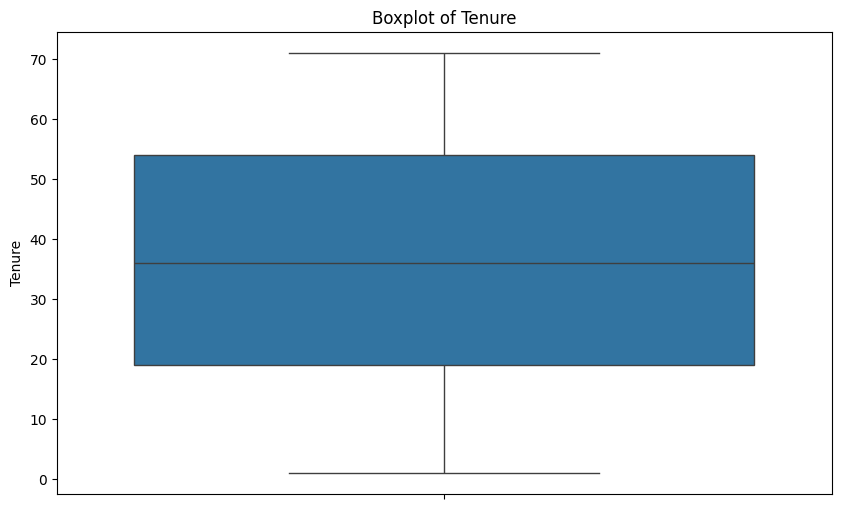

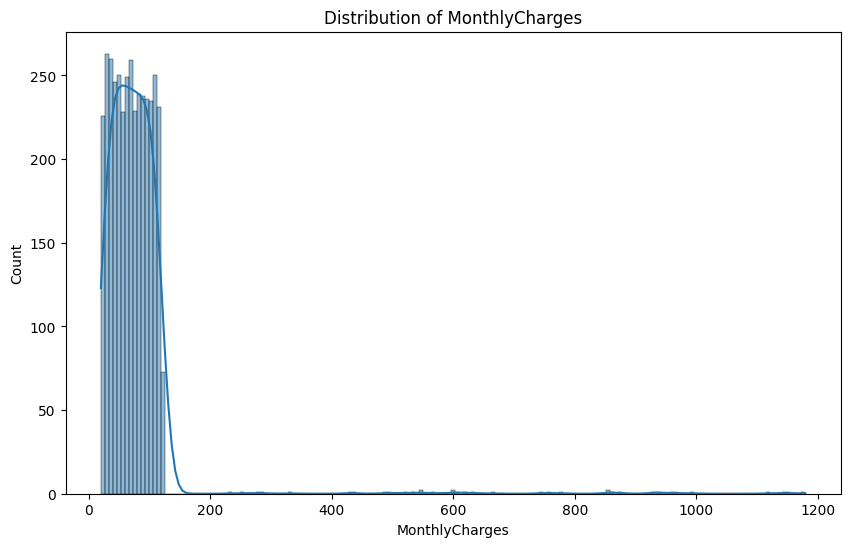

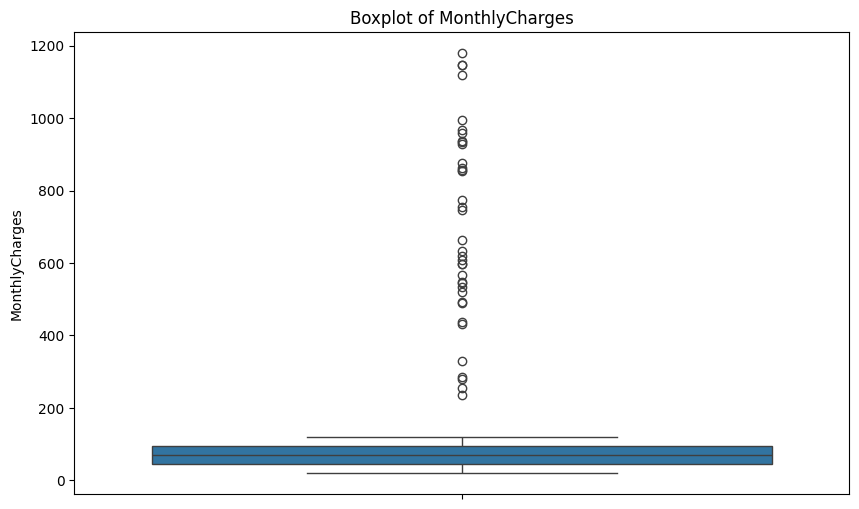

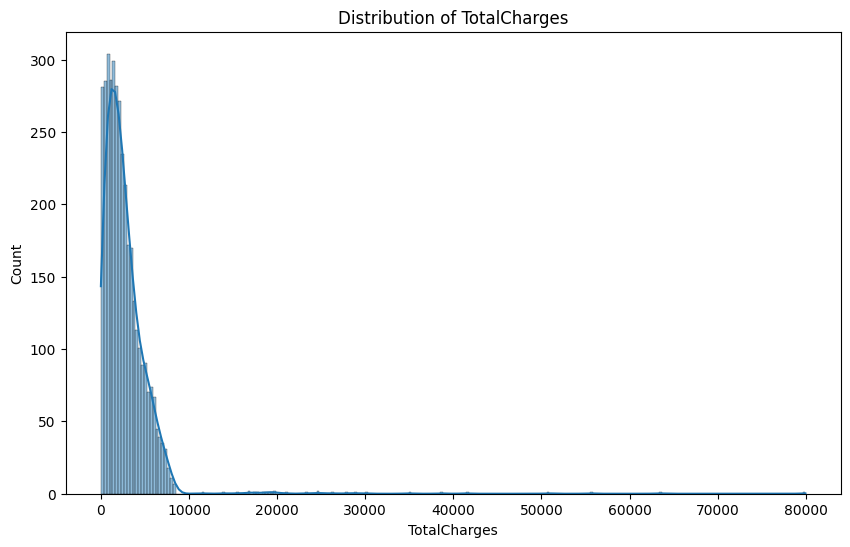

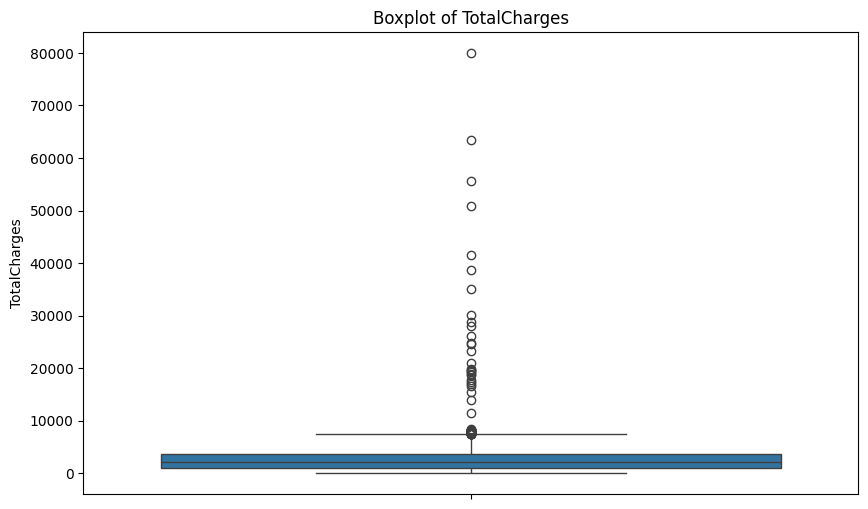

In [5]:
for col in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.figure(figsize=(10, 6))
    sns.boxplot(data[col])
    plt.title(f"Boxplot of {col}")


### preprocessing

In [6]:
#drop columns
data.drop(columns=['CustomerID','Unnamed: 0','Gender'],inplace=True)

### Null values and imputation method :
1. mean for age
2. random for payment method
3. random for service internet


In [7]:
data.isnull().sum()

Age                 187
Tenure                0
Service_Internet    721
Service_Phone         0
Service_TV            0
Contract              0
PaymentMethod       187
MonthlyCharges        0
TotalCharges          0
StreamingMovies       0
StreamingMusic        0
OnlineSecurity        0
TechSupport           0
Churn                 0
dtype: int64

In [8]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

In [9]:
def fill_na_random(data, str1, str2,str3,str4):
    return data.apply(lambda x: np.random.choice([str1, str2,str3,str4]) if pd.isna(x) else x)
data['PaymentMethod'] = fill_na_random(data['PaymentMethod'], 'Electronic check','Mailed check','Bank transfer','Credit card')
data['Service_Internet'] = fill_na_random(data['Service_Internet'], 'Fiber optic','DSL','Fiber optic','DSL')

Outliers and treating them with interquartile range

In [10]:
def treat_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5  * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    # Display the list of outliers
    outliers_list = outliers[col].tolist()
    print(f'outliers_list_{col}', outliers_list,len(outliers_list))

    # Capping outliers
    data[col] = np.where(data[col] > upper_bound, upper_bound,
                                 np.where(data[col] < lower_bound, lower_bound, data[col]))
    data[col] = np.ceil(data[col])

    return outliers_list

In [11]:
treat_outliers(data, 'MonthlyCharges')
treat_outliers(data, 'TotalCharges')

outliers_list_MonthlyCharges [492.8, 773.8, 255.1, 862.2, 929.8, 933.3, 491.0, 329.79999999999995, 597.3, 544.0999999999999, 959.9, 1119.1, 995.1, 875.0, 567.1, 1146.0, 967.4, 436.7000000000001, 1179.3000000000002, 607.3, 855.1, 278.7, 431.1, 1146.6, 755.6999999999999, 663.1999999999999, 548.8000000000001, 937.5, 597.2, 746.8000000000001, 518.8000000000001, 235.9, 632.2, 533.5, 856.3, 285.2, 619.9] 37
outliers_list_TotalCharges [7545.68, 7845.43, 28844.0, 7837.76, 7724.61, 15463.1, 19695.4, 7658.1, 7691.31, 7932.27, 7603.29, 11442.5, 7624.0, 7457.28, 18829.6, 7618.64, 8190.97, 8248.49, 17702.2, 7481.98, 7924.44, 50885.5, 8190.24, 7726.49, 19183.0, 8354.65, 7505.83, 79951.8, 8249.88, 18603.1, 7717.79, 8230.54, 35046.9, 7696.68, 7834.05, 7498.54, 30074.2, 16892.0, 23252.6, 7768.14, 7994.27, 41490.8, 27953.7, 7586.2, 8106.04, 7495.35, 8300.84, 7583.14, 7514.23, 7492.2, 24634.5, 19493.9, 16666.0, 26132.2, 7675.16, 8123.93, 38610.0, 20925.4, 7490.19, 7735.46, 55590.0, 7489.69, 19838.3, 1388

[7545.68,
 7845.43,
 28844.0,
 7837.76,
 7724.61,
 15463.1,
 19695.4,
 7658.1,
 7691.31,
 7932.27,
 7603.29,
 11442.5,
 7624.0,
 7457.28,
 18829.6,
 7618.64,
 8190.97,
 8248.49,
 17702.2,
 7481.98,
 7924.44,
 50885.5,
 8190.24,
 7726.49,
 19183.0,
 8354.65,
 7505.83,
 79951.8,
 8249.88,
 18603.1,
 7717.79,
 8230.54,
 35046.9,
 7696.68,
 7834.05,
 7498.54,
 30074.2,
 16892.0,
 23252.6,
 7768.14,
 7994.27,
 41490.8,
 27953.7,
 7586.2,
 8106.04,
 7495.35,
 8300.84,
 7583.14,
 7514.23,
 7492.2,
 24634.5,
 19493.9,
 16666.0,
 26132.2,
 7675.16,
 8123.93,
 38610.0,
 20925.4,
 7490.19,
 7735.46,
 55590.0,
 7489.69,
 19838.3,
 13887.8,
 7579.36,
 8032.4,
 63417.0,
 7942.48,
 8112.3,
 8021.1,
 17335.0,
 8055.2,
 24729.6]

<Axes: ylabel='TotalCharges'>

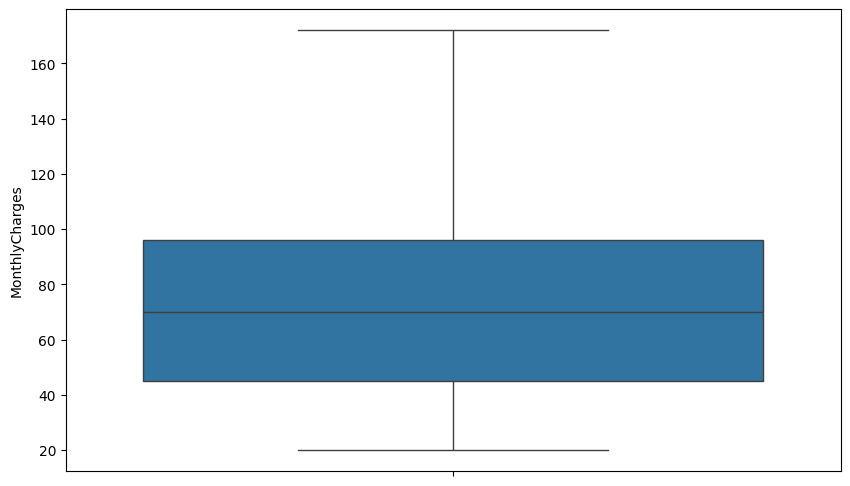

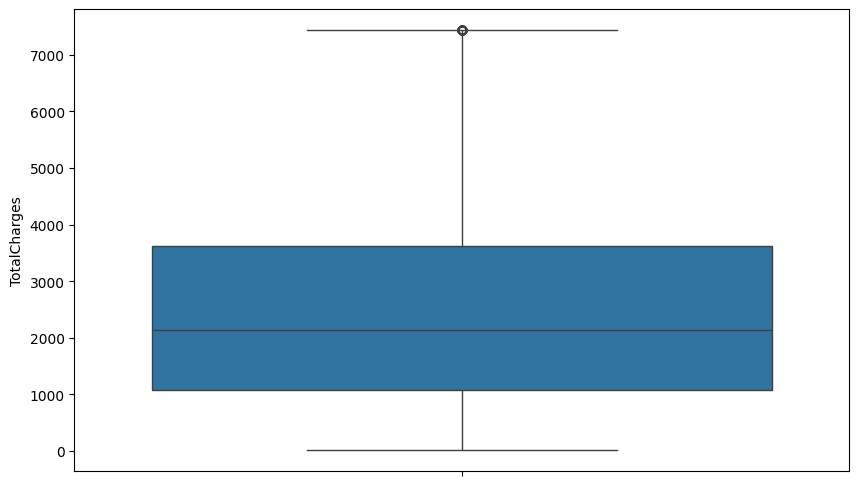

In [12]:
# boxplots to verify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data['MonthlyCharges'])
plt.figure(figsize=(10, 6))
sns.boxplot(data['TotalCharges'])

### Encoding variables



In [13]:
#run once
le = LabelEncoder()

In [14]:
le.fit((['Yes','No']))
categorical_columns = ['Service_Phone', 'Service_TV', 'StreamingMovies', 'StreamingMusic', 'OnlineSecurity', 'TechSupport','Churn']
for col in categorical_columns:
    data[col]  = le.transform(data[col])


In [15]:
le.fit(['DSL','Fiber optic'])
data['Service_Internet']= le.transform(data['Service_Internet'])  # if dsl =0, else 1

In [16]:
# label encoding contract and payment method
le.fit(['Bank transfer','Credit card','Electronic check','Mailed check']) #0,1,2,3
data['PaymentMethod']= le.transform(data['PaymentMethod'])

le.fit(['Month-to-month','One year','Two year']) 
data['Contract']= le.transform(data['Contract'])

In [17]:
data.head()

,Age,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,56.0,13,0,1,0,1,3,72.0,932.0,0,0,1,0,0
1,69.0,13,0,0,1,2,3,111.0,1449.0,1,1,0,0,0
2,46.0,60,1,0,1,0,3,117.0,6998.0,1,1,0,0,0
3,32.0,57,1,1,1,0,0,79.0,4453.0,0,1,0,1,0
4,60.0,52,1,1,1,2,2,31.0,1570.0,1,0,1,1,0


###  HYpothesis  testing  for categorical features

In [18]:
categorical_columns = ['Service_Internet', 'Service_Phone', 'Service_TV', 'Contract', 
'PaymentMethod', 'StreamingMovies', 'StreamingMusic', 'OnlineSecurity', 'TechSupport']

# Function to perform Chi-Square test
def chi_square_test(column):
    y  =  data['Churn']
    contingency_table = pd.crosstab(y, data[column])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {column}")
    print("Chi-Square Statistic:", chi2)
    print("P-value:", p)
    print("Degrees of Freedom:", dof)
    print("Expected Frequencies:\n", expected)
    if p < 0.05:
        print(f"Reject the null hypothesis: There is an association between Churn and {column}.\n")
    else:
        print(f"Fail to reject the null hypothesis: There is no association between Churn and {column}.\n")

# Perform Chi-Square test for each categorical column
for column in categorical_columns:
    chi_square_test(column)


Chi-Square Test for Service_Internet
Chi-Square Statistic: 0.24741512897527201
P-value: 0.6189010743049584
Degrees of Freedom: 1
Expected Frequencies:
 [[1382.77834089 2115.22165911]
 [  99.22165911  151.77834089]]
Fail to reject the null hypothesis: There is no association between Churn and Service_Internet.

Chi-Square Test for Service_Phone
Chi-Square Statistic: 1.2923503167972803
P-value: 0.25561526861194117
Degrees of Freedom: 1
Expected Frequencies:
 [[1052.47906108 2445.52093892]
 [  75.52093892  175.47906108]]
Fail to reject the null hypothesis: There is no association between Churn and Service_Phone.

Chi-Square Test for Service_TV
Chi-Square Statistic: 0.06952775669366028
P-value: 0.7920256103123289
Degrees of Freedom: 1
Expected Frequencies:
 [[1456.48919712 2041.51080288]
 [ 104.51080288  146.48919712]]
Fail to reject the null hypothesis: There is no association between Churn and Service_TV.

Chi-Square Test for Contract
Chi-Square Statistic: 1.4346578196119568
P-value: 0.4

### Correlation between features and the target variable - Churn

In [19]:
correlation = data.corr()['Churn'].sort_values(ascending=False)
print("Correlation with target variable:")
print(correlation)

Correlation with target variable:
Churn               1.000000
MonthlyCharges      0.216844
TechSupport         0.018568
Service_Internet    0.009215
Age                -0.003401
StreamingMovies    -0.004435
PaymentMethod      -0.005172
Service_TV         -0.005389
StreamingMusic     -0.009525
Contract           -0.011690
OnlineSecurity     -0.012379
Service_Phone      -0.019730
TotalCharges       -0.276758
Tenure             -0.392958
Name: Churn, dtype: float64


### Feature engineering

In [20]:
#age groups:
bins = [0, 30, 60, np.inf]
labels = [0, 1, 2] #0 = 0:30, 1= 30:60, 2 = 60 and above
data['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels)
data['Age_Group']=data['Age_Group'].astype(int)
data.drop(columns=['Age'],inplace=True)

In [21]:
data['Charges_Per_Tenure'] = data['TotalCharges'] / data['Tenure']#avg monthly charges

In [22]:
#no of times contract renewed
# month to minth = 0, one year =1 ,two year = 2
# if tenure = 13 and contract = month to month , renewal = 13
# if tenure = 53 and contract = 2 year , renewal = 3 

def calculate_renewals(row):
    tenure = row['Tenure']
    contract = row['Contract']
    
    if contract == 0:
        return tenure
    elif contract == 1:
        return tenure // 12
    elif contract == 2:
        return tenure // 24
    else:
        return 0
    
data['renewal'] = data.apply(calculate_renewals, axis=1)


In [23]:
#total services
service_columns = ['Service_Internet', 'Service_Phone', 'Service_TV', 'StreamingMovies', 'StreamingMusic', 'OnlineSecurity', 'TechSupport']
data['Total_Services_Added'] = data[service_columns].sum(axis=1)
#average charge per service
data['average_charge_per_service'] = data['TotalCharges']/(data['Total_Services_Added']+1)


In [24]:
new_col = ['Age_Group','Charges_Per_Tenure','renewal','Total_Services_Added','average_charge_per_service']
data[new_col].head()

,Age_Group,Charges_Per_Tenure,renewal,Total_Services_Added,average_charge_per_service
0,1,71.692308,1.0,2,310.666667
1,2,111.461538,0.0,3,362.250000
2,1,116.633333,60.0,4,1399.600000
3,1,78.122807,57.0,5,742.166667
4,1,30.192308,2.0,6,224.285714


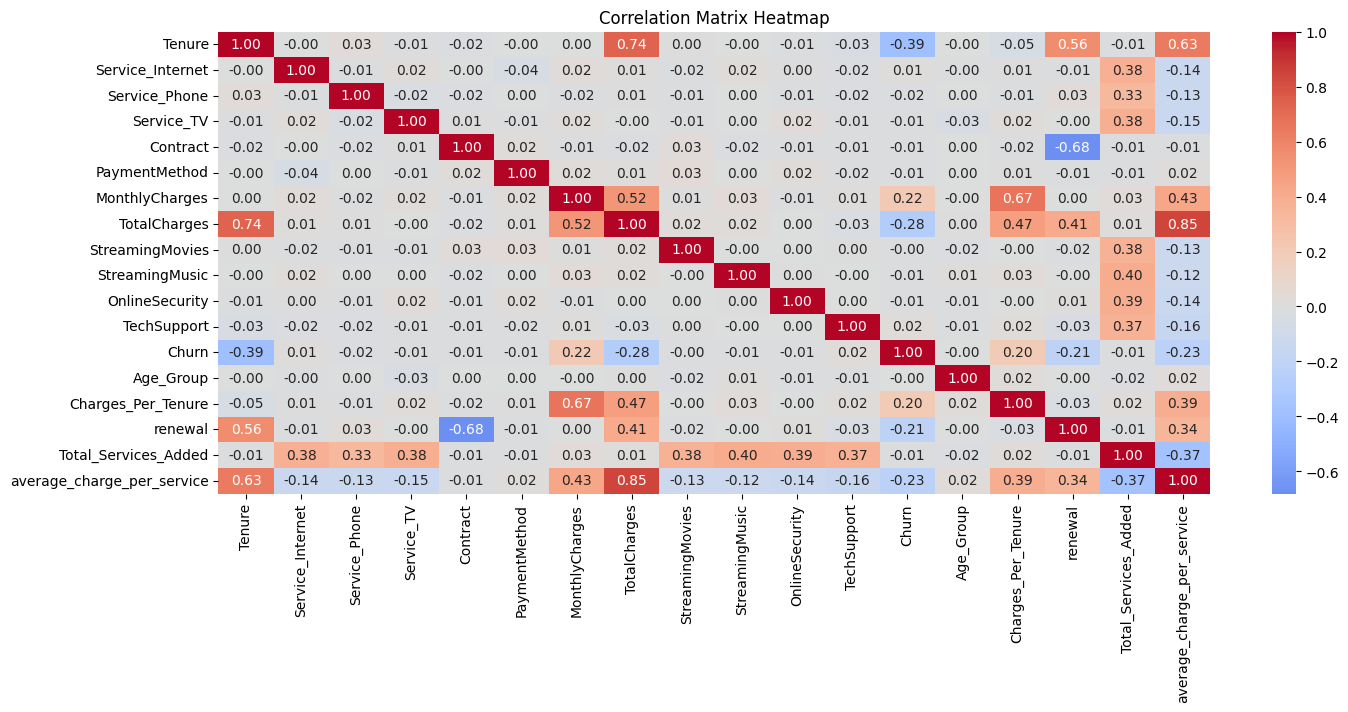

In [25]:
#correleation matrix for new features
corr_mat= data.corr()
plt.figure(figsize=(16, 6))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', center=0,fmt = ".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [26]:
for col in data.columns:
    value_counts= data[col].value_counts()
    print(f" value counts for {col}: {value_counts}")

 value counts for Tenure: Tenure
26    71
58    69
71    66
17    63
33    63
      ..
32    42
34    41
40    40
8     39
5     33
Name: count, Length: 71, dtype: int64
 value counts for Service_Internet: Service_Internet
1    2267
0    1482
Name: count, dtype: int64
 value counts for Service_Phone: Service_Phone
1    2621
0    1128
Name: count, dtype: int64
 value counts for Service_TV: Service_TV
1    2188
0    1561
Name: count, dtype: int64
 value counts for Contract: Contract
0    2183
2     792
1     774
Name: count, dtype: int64
 value counts for PaymentMethod: PaymentMethod
2    1457
0     792
3     773
1     727
Name: count, dtype: int64
 value counts for MonthlyCharges: MonthlyCharges
68.0     56
76.0     52
97.0     50
62.0     49
109.0    47
         ..
113.0    29
75.0     28
49.0     28
105.0    27
20.0      1
Name: count, Length: 102, dtype: int64
 value counts for TotalCharges: TotalCharges
7435.0    73
2099.0     5
1978.0     5
1621.0     5
2356.0     5
          ..
18

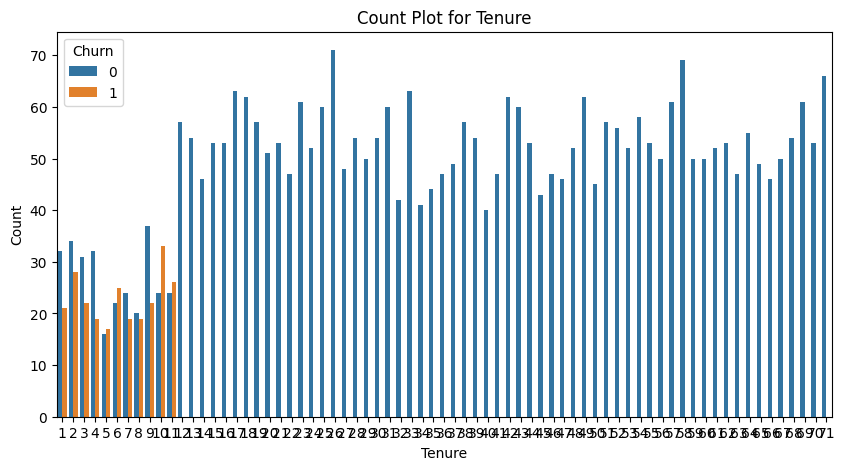

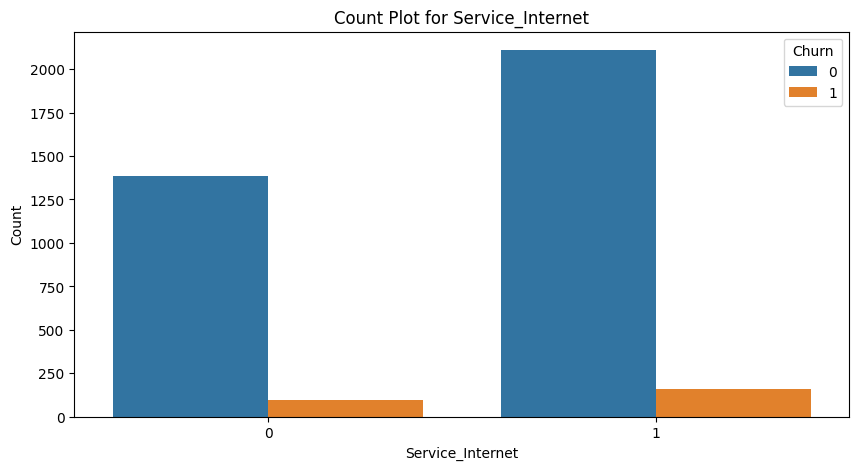

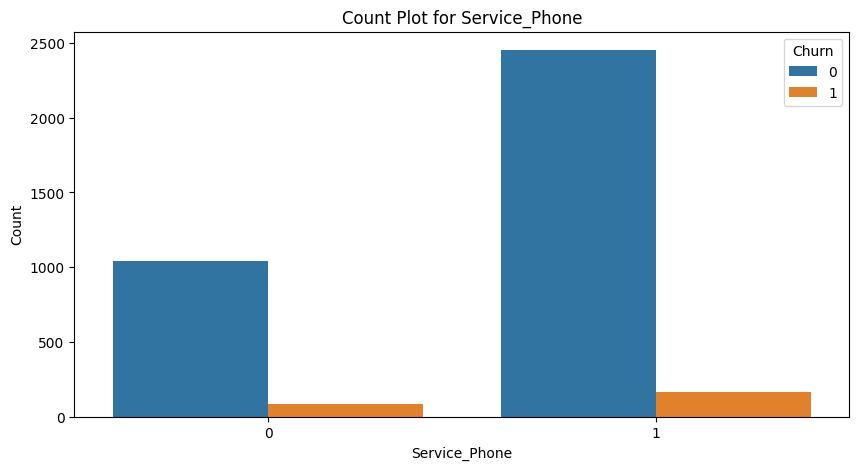

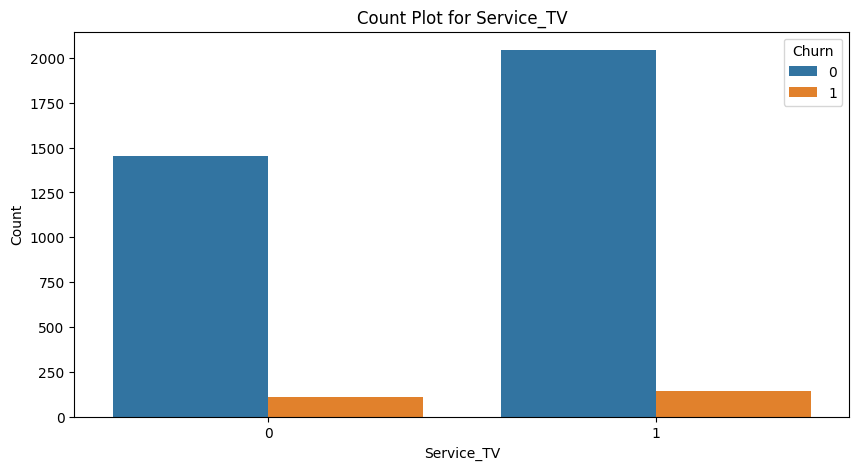

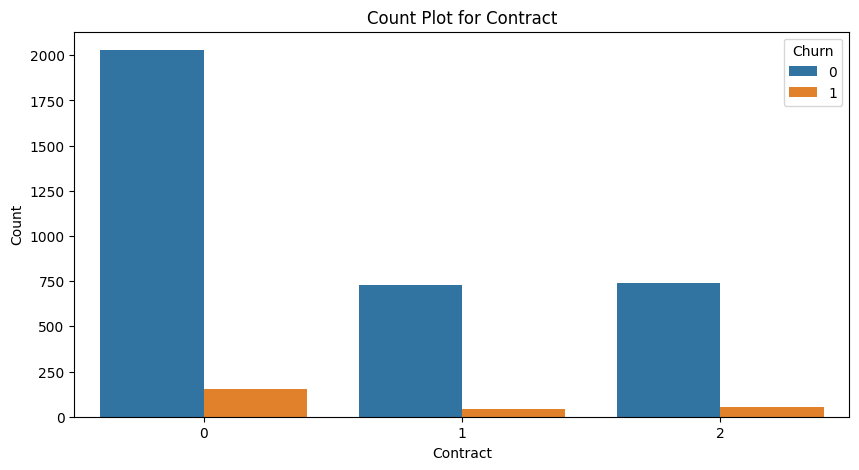

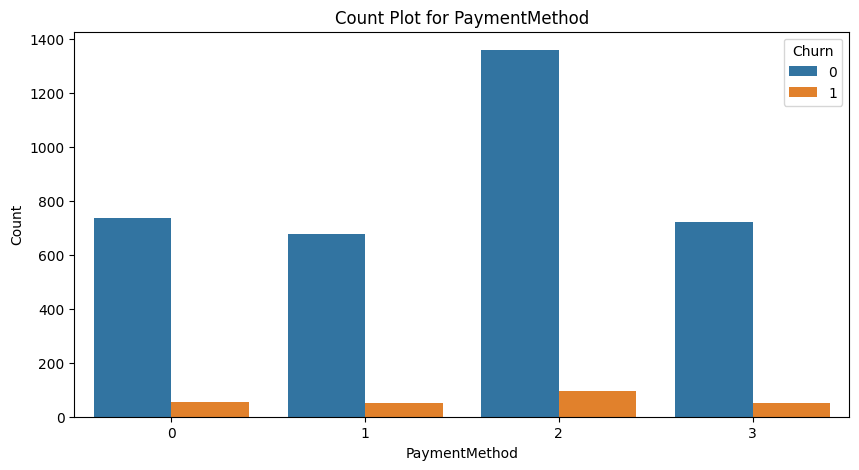

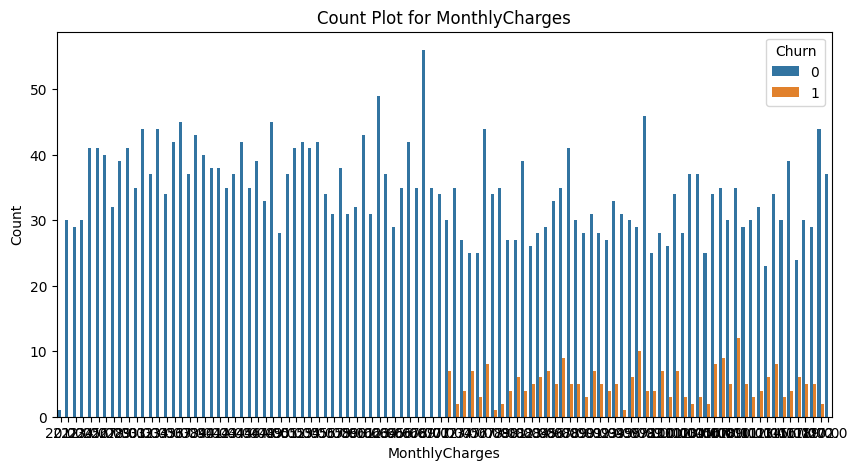

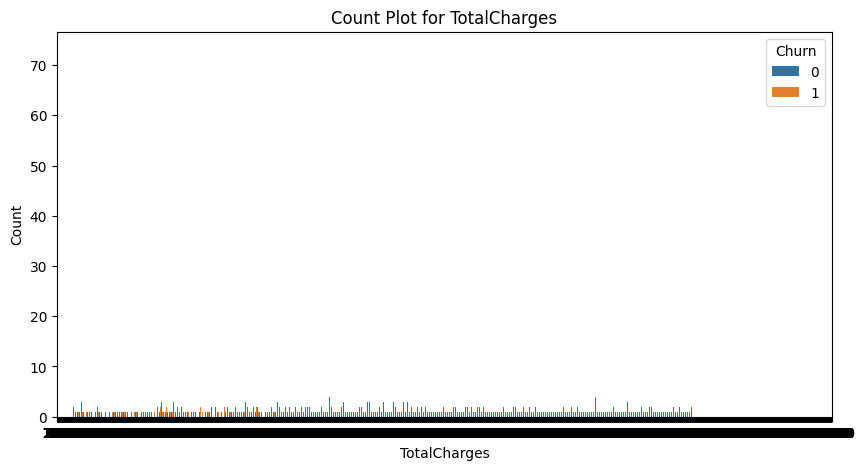

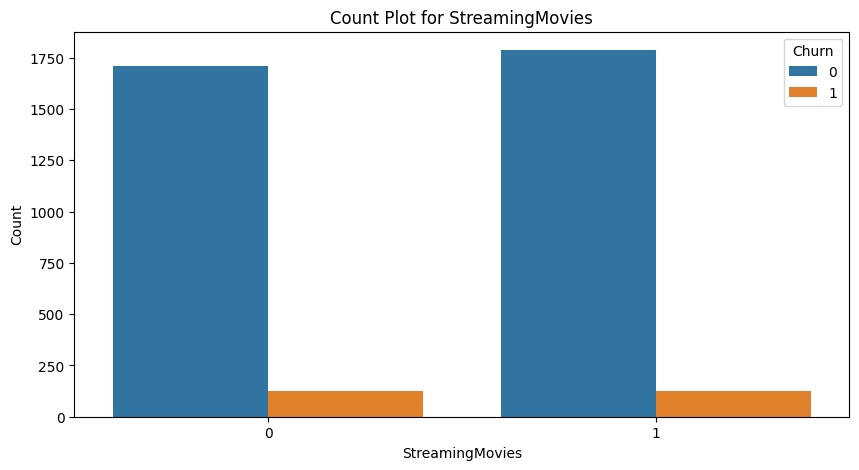

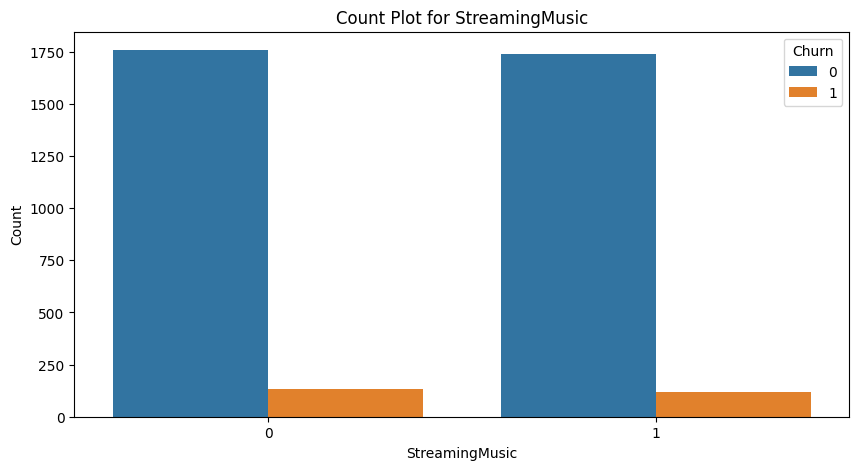

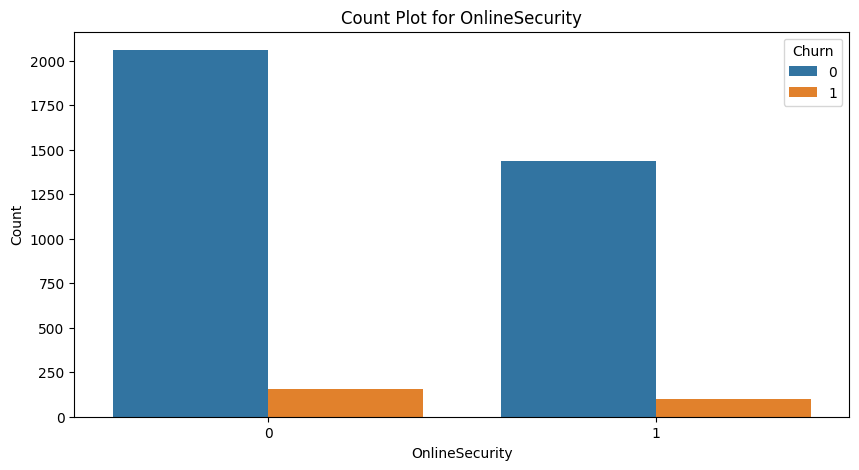

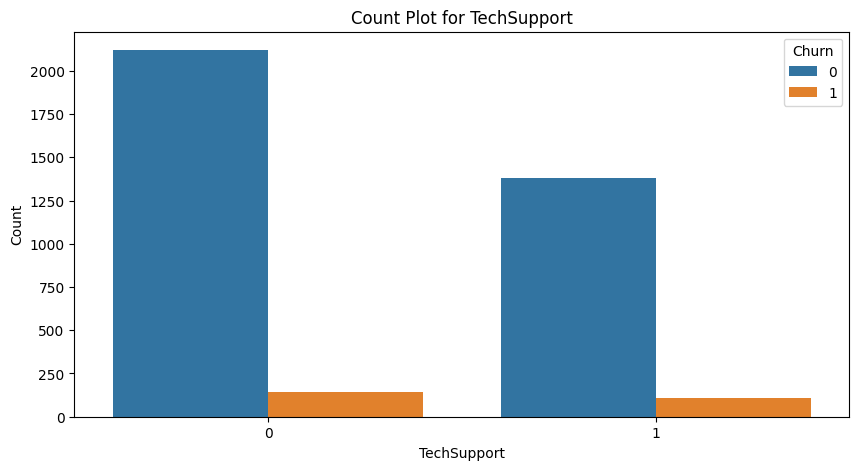

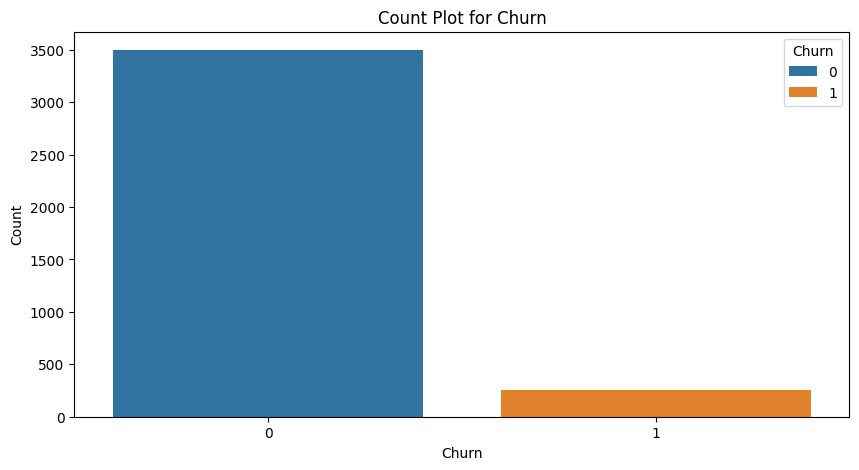

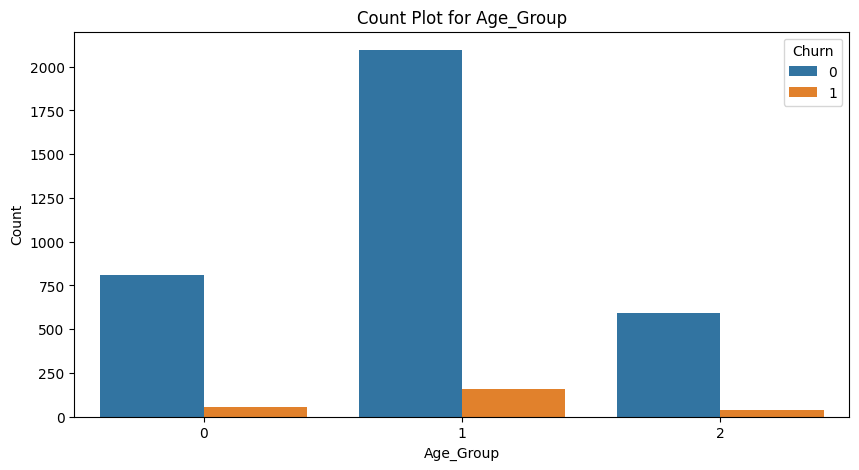

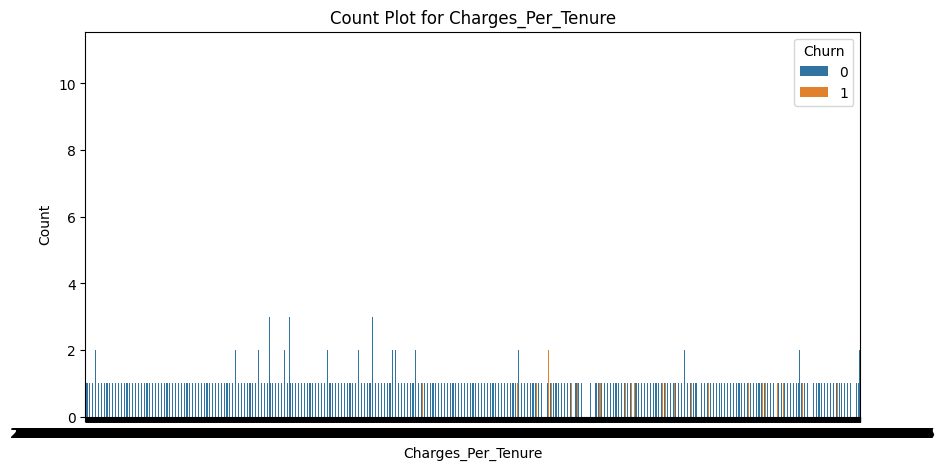

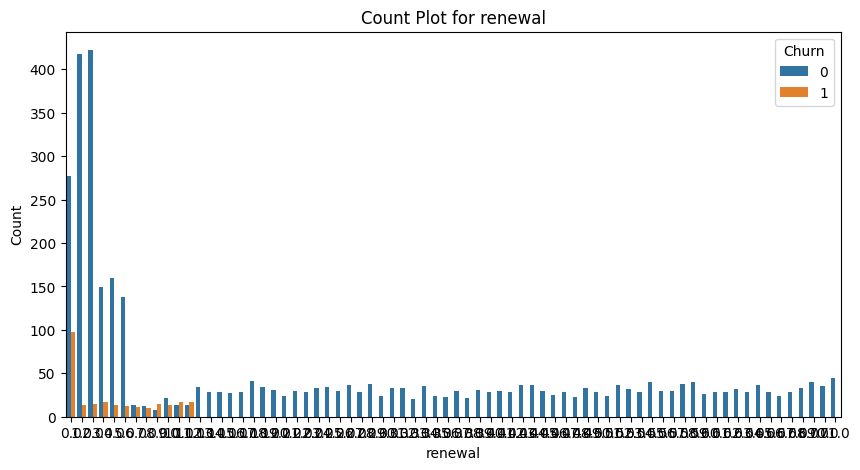

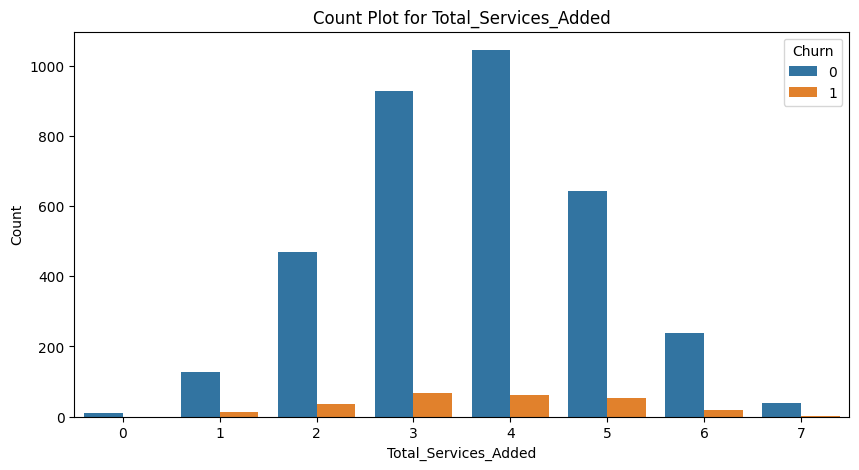

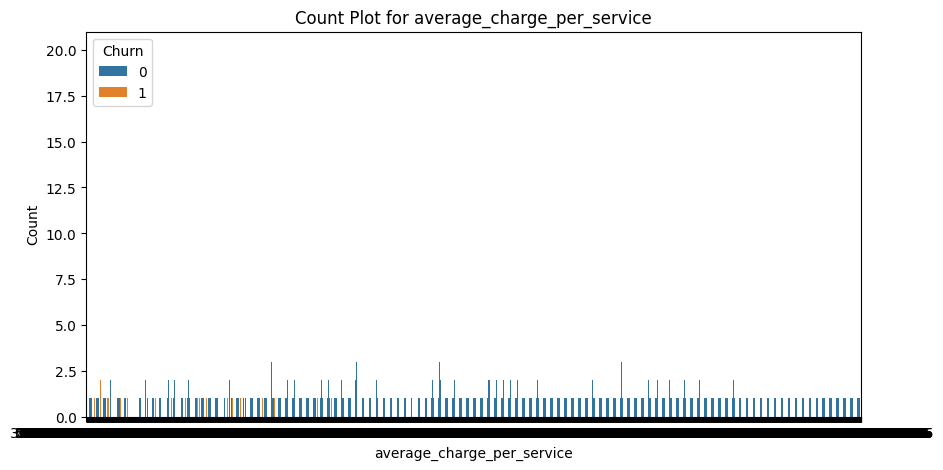

In [27]:
for column in data.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=column, hue='Churn', data=data)
    plt.title(f'Count Plot for {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

### scale

In [28]:
min_max = MinMaxScaler()
min_max.fit(data)

scaled_data = min_max.transform(data)
df = pd.DataFrame(scaled_data, columns=data.columns)

In [29]:
#df.to_csv("data_cleaned.csv")
df.head()

,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn,Age_Group,Charges_Per_Tenure,renewal,Total_Services_Added,average_charge_per_service
0,0.171429,0.0,1.0,0.0,0.5,1.000000,0.342105,0.123703,0.0,0.0,1.0,0.0,0.0,0.5,0.054375,0.014085,0.285714,0.058942
1,0.171429,0.0,0.0,1.0,1.0,1.000000,0.598684,0.193370,1.0,1.0,0.0,0.0,0.0,1.0,0.091858,0.000000,0.428571,0.068818
2,0.842857,1.0,0.0,1.0,0.0,1.000000,0.638158,0.941113,1.0,1.0,0.0,0.0,0.0,0.5,0.096733,0.845070,0.571429,0.267422
3,0.800000,1.0,1.0,1.0,0.0,0.000000,0.388158,0.598167,0.0,1.0,0.0,1.0,0.0,0.5,0.060436,0.802817,0.714286,0.141554
4,0.728571,1.0,1.0,1.0,1.0,0.666667,0.072368,0.209675,1.0,0.0,1.0,1.0,0.0,0.5,0.015261,0.028169,0.857143,0.042404


### Feature selection

In [30]:
y = df['Churn']
df.drop(columns='Churn',inplace=True)

In [31]:
model = RandomForestClassifier()
model.fit(df,y)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")

for f in range(df.shape[1]):
    print("%d. %s (%f)" % (f + 1, df.columns[indices[f]], importances[indices[f]]))

Feature ranking:
1. Tenure (0.308674)
2. MonthlyCharges (0.254160)
3. Charges_Per_Tenure (0.177707)
4. TotalCharges (0.118177)
5. average_charge_per_service (0.093193)
6. renewal (0.032219)
7. Contract (0.004174)
8. Total_Services_Added (0.003868)
9. PaymentMethod (0.001029)
10. StreamingMovies (0.000974)
11. Service_Internet (0.000959)
12. TechSupport (0.000953)
13. StreamingMusic (0.000916)
14. OnlineSecurity (0.000909)
15. Age_Group (0.000769)
16. Service_TV (0.000709)
17. Service_Phone (0.000609)


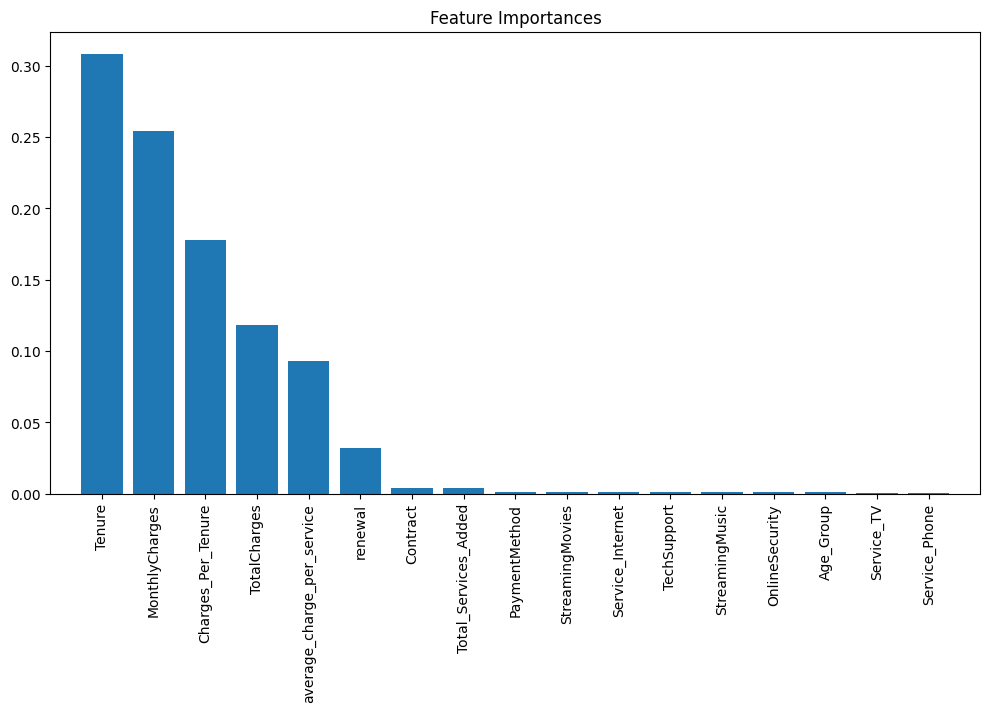

In [32]:
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(df.shape[1]), importances[indices], align='center')
plt.xticks(range(df.shape[1]), df.columns[indices], rotation=90)
plt.xlim([-1, df.shape[1]])
plt.show()

In [33]:
#rfe  on   decisionn tree
estimator = DecisionTreeClassifier()
rfe  = RFE(estimator=estimator)
rfe.fit(df, y)
importances = rfe.ranking_
indices = np.argsort(importances)[::]
for f in range(df.shape[1]):
    print("%d. %s (%f)" % (f + 1, df.columns[indices[f]], importances[indices[f]]))

1. Tenure (1.000000)
2. renewal (1.000000)
3. Charges_Per_Tenure (1.000000)
4. Age_Group (1.000000)
5. TechSupport (1.000000)
6. Total_Services_Added (1.000000)
7. average_charge_per_service (1.000000)
8. MonthlyCharges (1.000000)
9. OnlineSecurity (2.000000)
10. StreamingMusic (3.000000)
11. TotalCharges (4.000000)
12. PaymentMethod (5.000000)
13. Contract (6.000000)
14. Service_TV (7.000000)
15. Service_Phone (8.000000)
16. Service_Internet (9.000000)
17. StreamingMovies (10.000000)


In [34]:
#SFS on logistic
sfs = SFS(estimator=LogisticRegression(),n_features_to_select=9,direction='forward')
sfs.fit(df,y)
importances = sfs.support_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(df.shape[1]):
    print("%d.  %s (%f)" % (f + 1, df.columns[indices[f]], importances[indices[f]]))

Feature ranking:
1.  average_charge_per_service (1.000000)
2.  TotalCharges (1.000000)
3.  Service_Phone (1.000000)
4.  Service_TV (1.000000)
5.  MonthlyCharges (1.000000)
6.  Tenure (1.000000)
7.  TechSupport (1.000000)
8.  Charges_Per_Tenure (1.000000)
9.  renewal (1.000000)
10.  OnlineSecurity (0.000000)
11.  StreamingMusic (0.000000)
12.  Total_Services_Added (0.000000)
13.  Age_Group (0.000000)
14.  PaymentMethod (0.000000)
15.  Contract (0.000000)
16.  Service_Internet (0.000000)
17.  StreamingMovies (0.000000)


In [35]:
df2 = pd.DataFrame(df,columns=['Tenure','MonthlyCharges','Charges_Per_Tenure','average_charge_per_service','TotalCharges','renewal','Contract','Total_Services_Added','PaymentMethod'])

### Model training

In [36]:
X_train,x_test,y_train,y_test = train_test_split(df2,y,test_size= 0.20,random_state =42)

In [37]:
"""#file created already
X_train.to_csv("X_train.csv")
x_test.to_csv("X_test.csv")
y_train.to_csv("Y_train.csv")
y_test.to_csv("Y_test.csv")"""

'#file created already\nX_train.to_csv("X_train.csv")\nx_test.to_csv("X_test.csv")\ny_train.to_csv("Y_train.csv")\ny_test.to_csv("Y_test.csv")'

In [38]:
#Cross validation is a machine learning technique to evaluate 
# #a model's performance on unseen data. It involves dividing 
#the available data into multiple folds or subsets, using one 
# #of these folds as a validation set, and training the model 
# #on the remaining folds. This process is repeated multiple 
# #times using a different fold as the validation set. Finally, 
# #the results from each validation step are averaged to 
# #produce a more robust estimate of the model’s performance

In [39]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),#maximum likelihood  
    'KNN':KNeighborsClassifier(n_neighbors=3),
    'Poly_SVC': SVC(kernel="poly", degree=3, coef0=1, C=5),
    'sgd': SGDClassifier(),
    'rf': RandomForestClassifier(),
}

Logistic Regression Cross-Validation Accuracy: 0.962320534223706
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2791
         1.0       0.94      0.54      0.69       208

    accuracy                           0.97      2999
   macro avg       0.95      0.77      0.84      2999
weighted avg       0.97      0.97      0.96      2999



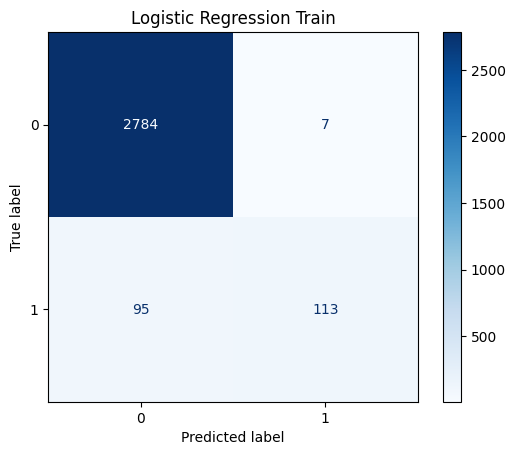

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       707
         1.0       0.88      0.53      0.67        43

    accuracy                           0.97       750
   macro avg       0.93      0.77      0.83       750
weighted avg       0.97      0.97      0.97       750



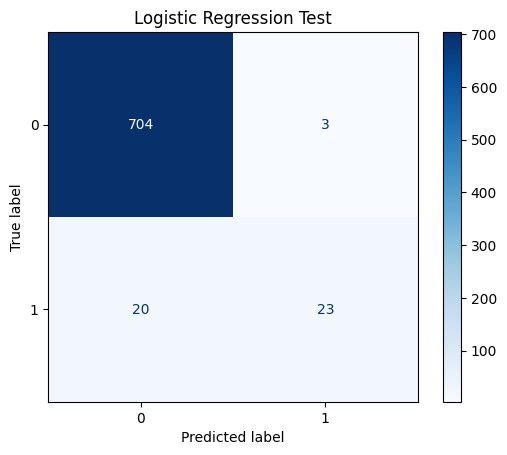

KNN Cross-Validation Accuracy: 0.9743266555370061
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      2791
         1.0       0.97      0.90      0.94       208

    accuracy                           0.99      2999
   macro avg       0.98      0.95      0.97      2999
weighted avg       0.99      0.99      0.99      2999



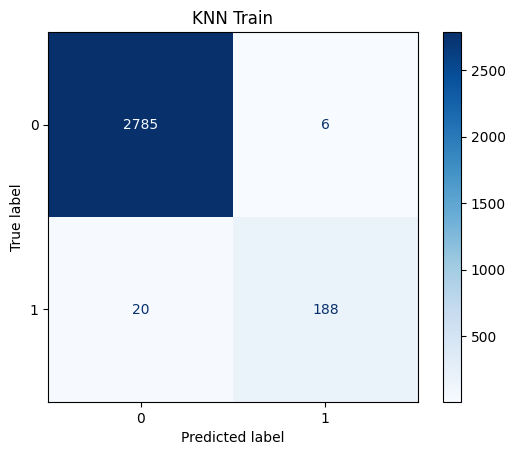

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       707
         1.0       0.83      0.79      0.81        43

    accuracy                           0.98       750
   macro avg       0.91      0.89      0.90       750
weighted avg       0.98      0.98      0.98       750



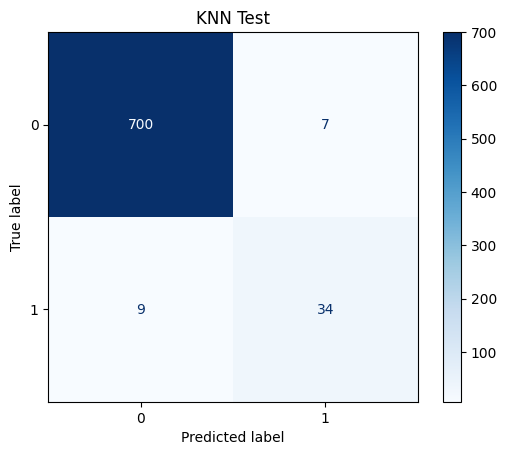

Poly_SVC Cross-Validation Accuracy: 0.9889944351697274
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      2791
         1.0       0.97      0.90      0.94       208

    accuracy                           0.99      2999
   macro avg       0.98      0.95      0.97      2999
weighted avg       0.99      0.99      0.99      2999



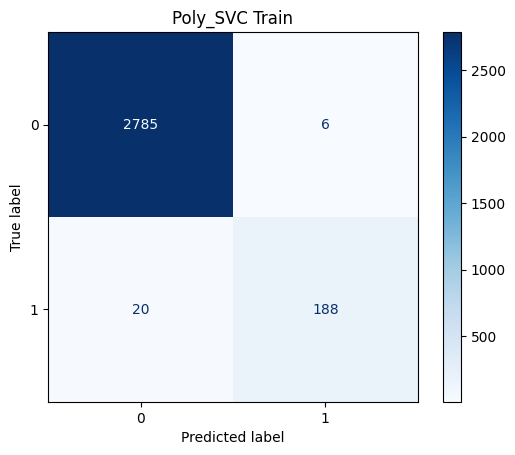

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       707
         1.0       0.91      0.93      0.92        43

    accuracy                           0.99       750
   macro avg       0.95      0.96      0.96       750
weighted avg       0.99      0.99      0.99       750



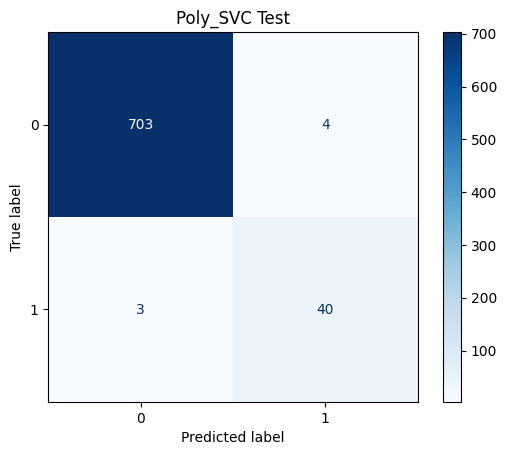

sgd Cross-Validation Accuracy: 0.9643227601558152
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2791
         1.0       0.86      0.80      0.83       208

    accuracy                           0.98      2999
   macro avg       0.92      0.89      0.91      2999
weighted avg       0.98      0.98      0.98      2999



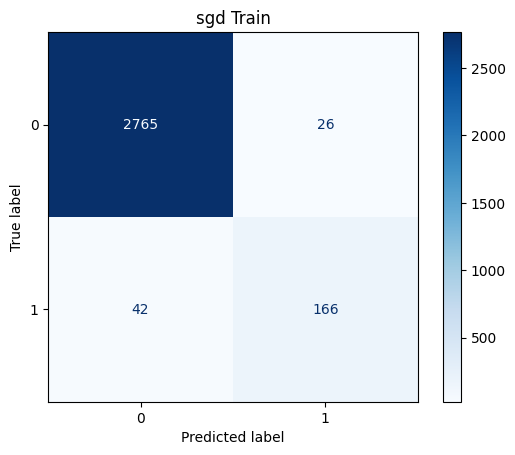

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       707
         1.0       0.84      0.72      0.78        43

    accuracy                           0.98       750
   macro avg       0.91      0.86      0.88       750
weighted avg       0.97      0.98      0.98       750



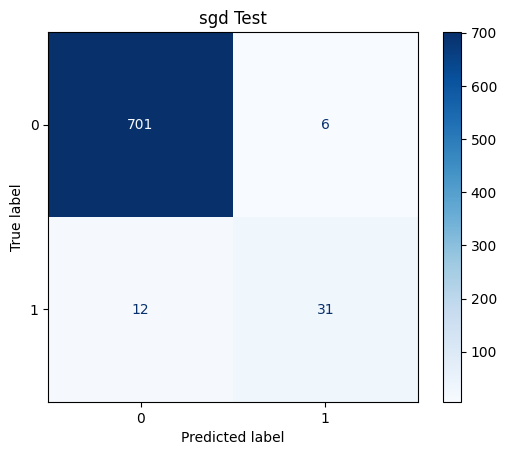

rf Cross-Validation Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2791
         1.0       1.00      1.00      1.00       208

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999



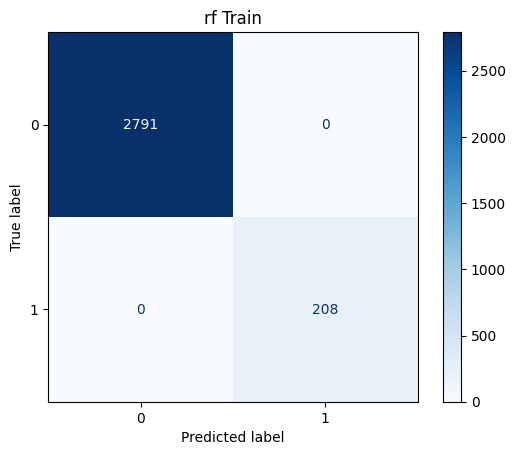

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       707
         1.0       0.98      1.00      0.99        43

    accuracy                           1.00       750
   macro avg       0.99      1.00      0.99       750
weighted avg       1.00      1.00      1.00       750



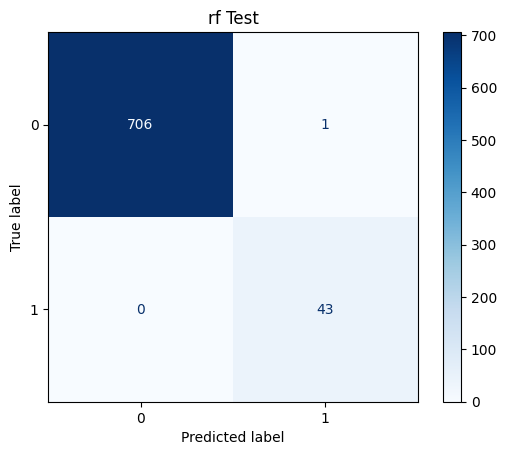

In [40]:

# Iterate over classifiers and perform cross-validation
for clf_name, clf in classifiers.items():
    pipeline = Pipeline([
        ('classifier', clf)
    ])
    # Perform cross-validation on the training set
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(f'{clf_name} Cross-Validation Accuracy: {scores.mean()}')

    # Fitting the classifier to the training data
    pipeline.fit(X_train, y_train)

    # Predict on train and test set
    y_train_pred = pipeline.predict(X_train)
    y_pred = pipeline.predict(x_test)

    
    # Performance and confusion  matrix
    print(classification_report(y_train, y_train_pred)) 
    cm_train = confusion_matrix(y_train,y_train_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name} Train')
    plt.show()

    print(classification_report(y_test,y_pred))
    cm_test = confusion_matrix(y_test,y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name} Test')
    plt.show()


    #save models
    # models created
    #model_filename = f'{clf_name.replace(" ", "_")}_model.pkl'
    #with open(model_filename, 'wb') as file:
        #pickle.dump(clf,file)


#load model
#model_filename =path/to/model
# pickled_model = pickle.load(open(model_filename, 'rb'))
#pickled_model.predict(x_test)


### Hyppertuning

In [41]:
classifiers = {'sgd':SGDClassifier(),
               'rf':RandomForestClassifier(),
               'polysvc':SVC(kernel ='poly')}

param_grid = {
    'rf': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    },
    'sgd': {
        'clf__loss': ['hinge', 'log_loss', 'modified_huber'],
        'clf__penalty': ['l2', 'l1', 'elasticnet'],
        'clf__alpha': [0.0001, 0.001, 0.01],
        'clf__learning_rate': ['constant', 'optimal', 'invscaling'],
        'clf__eta0': [0.01, 0.1, 1],
        'clf__max_iter': [1000, 2000, 3000]
    },
    'polysvc': {
        'clf__degree': [1, 2, 3,5,7],
        'clf__coef0': [1, 2, 3,5,7],
        'clf__C': [1, 3, 5, 7,9]
    }
}

Tuning sgd...
Best parameters found: {'clf__alpha': 0.0001, 'clf__eta0': 0.01, 'clf__learning_rate': 'optimal', 'clf__loss': 'hinge', 'clf__max_iter': 2000, 'clf__penalty': 'elasticnet'}
Best cross-validation accuracy: 0.9763266555370063
Train set performance:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      2791
         1.0       0.72      0.89      0.79       208

    accuracy                           0.97      2999
   macro avg       0.85      0.93      0.89      2999
weighted avg       0.97      0.97      0.97      2999



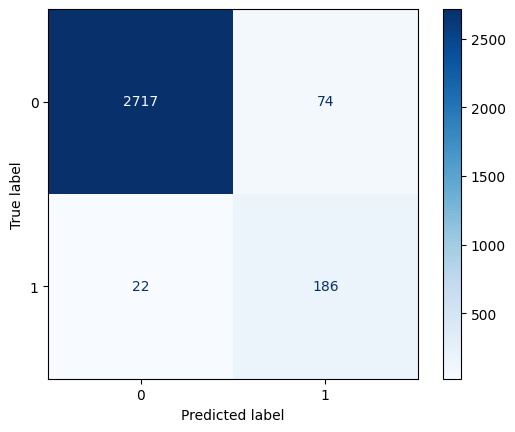

Best parameters found: {'clf__alpha': 0.0001, 'clf__eta0': 0.01, 'clf__learning_rate': 'optimal', 'clf__loss': 'hinge', 'clf__max_iter': 2000, 'clf__penalty': 'elasticnet'}
Best cross-validation accuracy: 0.9763266555370063
Test set performance:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       707
         1.0       0.73      0.93      0.82        43

    accuracy                           0.98       750
   macro avg       0.86      0.95      0.90       750
weighted avg       0.98      0.98      0.98       750



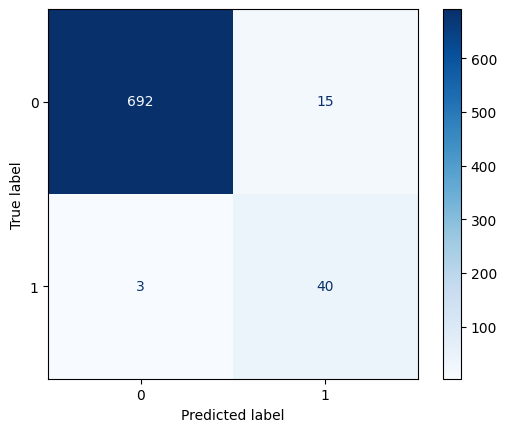

Tuning rf...
Best parameters found: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best cross-validation accuracy: 1.0
Train set performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2791
         1.0       1.00      1.00      1.00       208

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999



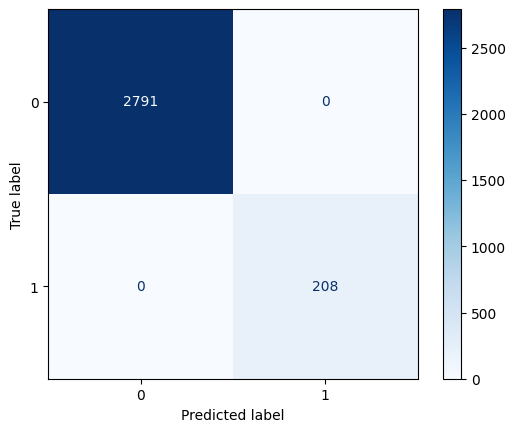

Best parameters found: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best cross-validation accuracy: 1.0
Test set performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       707
         1.0       0.98      1.00      0.99        43

    accuracy                           1.00       750
   macro avg       0.99      1.00      0.99       750
weighted avg       1.00      1.00      1.00       750



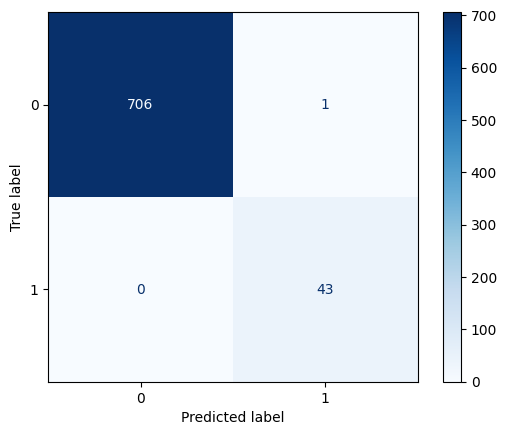

Tuning polysvc...
Best parameters found: {'clf__C': 9, 'clf__coef0': 7, 'clf__degree': 3}
Best cross-validation accuracy: 0.9949988870339455
Train set performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2791
         1.0       0.99      0.99      0.99       208

    accuracy                           1.00      2999
   macro avg       0.99      0.99      0.99      2999
weighted avg       1.00      1.00      1.00      2999



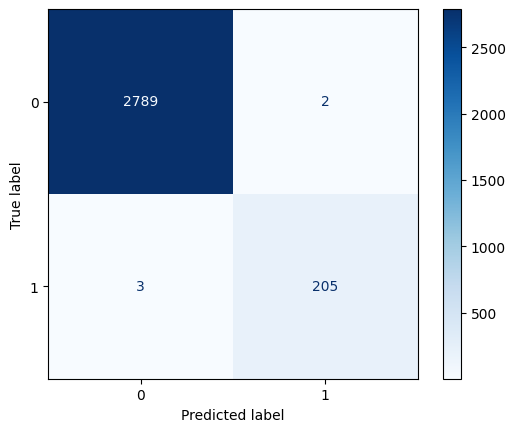

Best parameters found: {'clf__C': 9, 'clf__coef0': 7, 'clf__degree': 3}
Best cross-validation accuracy: 0.9949988870339455
Test set performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       707
         1.0       0.95      0.93      0.94        43

    accuracy                           0.99       750
   macro avg       0.97      0.96      0.97       750
weighted avg       0.99      0.99      0.99       750



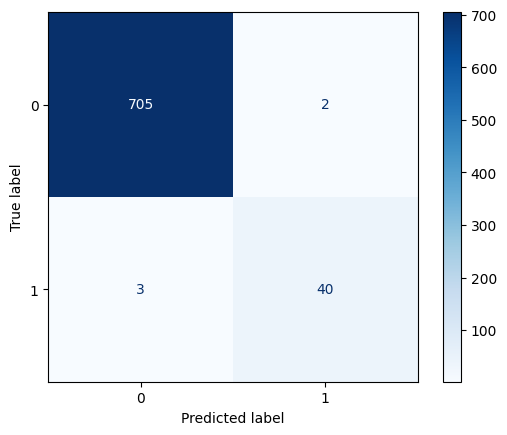

In [42]:

#  hyperparameter grid
for clf_name, clf in classifiers.items():
    print(f"Tuning {clf_name}...")
    pipeline = Pipeline([
        ('clf', clf)
    ])
    
    grid_search = GridSearchCV(pipeline, param_grid[clf_name], cv=5, n_jobs=-1, scoring='accuracy')

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_


#evaluate on training
    y_train_pred = best_model.predict(X_train)
    print("Best parameters found:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)
    print("Train set performance:")
    print(classification_report(y_train, y_train_pred))
    cm = confusion_matrix(y_train,y_train_pred)
# Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

# Make predictionson test
    y_pred = best_model.predict(x_test)
    print("Best parameters found:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)
    print("Test set performance:")
    print(classification_report(y_test, y_pred))
    cm2 = confusion_matrix(y_test,y_pred)
# Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
#save model
    #model_filename = f'{clf_name.replace(" ", "_")}_tuned_model.pkl'
    #with open(model_filename, 'wb') as file:
        #pickle.dump(best_model,file)

#load model
# model_filename =path/to/model
# pickled_model = pickle.load(open(model_filename, 'rb'))
#pickled_model.predict(x_test)